In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [2]:
# Read the CSV and parse dates
merged_df = pd.read_csv('merged_data.csv', parse_dates=['Date'])
merged_df.set_index('Date', inplace=True)

# Filter by date range
start_date = '2017-01-01'
end_date = '2018-12-31'
merged_df = merged_df[(merged_df.index >= start_date) & (merged_df.index <= end_date)]

/var/folders/07/l8m36_9s2lz170jptjv7r6jc0000gn/T/ipykernel_36021/2263201366.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  merged_df = pd.read_csv('merged_data.csv', parse_dates=['Date'])


In [1]:
# Convert all input to numeric
prices = merged_df.apply(pd.to_numeric, errors='coerce')

# Fill NaN values with column mean
# def fill_by_mean(df):
#     df = df.replace([np.inf, -np.inf], np.nan)
#     return df.fillna(df.mean())
# prices = fill_by_mean(merged_df)

# Check
prices.head()

NameError: name 'merged_df' is not defined

In [4]:
stocks = prices.columns
returns = prices.pct_change().dropna()
log_prices = np.log(prices)
log_returns = log_prices.diff().dropna()

form_start = '2017-01-01'
form_end = '2017-12-31'

trade_start = '2018-01-01'
trade_end = '2018-12-31'

prices_form = prices.loc[form_start:form_end]
prices_trade = prices.loc[trade_start:trade_end]

log_prices_form = log_prices.loc[form_start:form_end]
log_prices_trade = log_prices.loc[trade_start:trade_end]

log_returns_form = log_returns.loc[form_start:form_end]
log_returns_trade = log_returns.loc[trade_start:trade_end]

returns_form = returns.loc[form_start:form_end]
returns_trade = returns.loc[trade_start:trade_end]

In [5]:
from statsmodels.tsa.stattools import adfuller
import statsmodels.api as sm
import pandas as pd

def engle_granger_test(series1, series2, verbose=True):
    """
    Performs the Engle-Granger two-step cointegration test.
    Returns True if the two series are cointegrated, False otherwise.
    """

    # Ensure input is pandas Series
    series1 = pd.Series(series1)
    series2 = pd.Series(series2)

    # Step 1: Check if both series are I(1) - non-stationary in levels, stationary in first difference
    def is_I1(series, name='Series'):
        adf_level = adfuller(series, autolag='AIC')
        adf_diff = adfuller(series.diff().dropna(), autolag='AIC')
        if verbose:
            print(f"ADF test for {name} (level): p-value = {adf_level[1]:.4f}")
            print(f"ADF test for {name} (1st diff): p-value = {adf_diff[1]:.4f}")
        return adf_level[1] > 0.05 and adf_diff[1] < 0.05

    is_I1_series1 = is_I1(series1, 'Series 1')
    is_I1_series2 = is_I1(series2, 'Series 2')

    if not (is_I1_series1 and is_I1_series2):
        if verbose:
            print("At least one series is not I(1). Cannot proceed with Engle-Granger test.")
        return False

    # Step 2: Regress series1 on series2
    model = sm.OLS(series1, sm.add_constant(series2)).fit()
    residuals = model.resid

    # ADF test on residuals
    adf_resid = adfuller(residuals, autolag='AIC')
    if verbose:
        print(f"\nADF test on residuals: p-value = {adf_resid[1]:.4f}")

    # If residuals are stationary, series are cointegrated
    return adf_resid[1] < 0.05

In [6]:
from itertools import combinations
# Filter out stocks with constant prices
valid_stocks = [stock for stock in stocks if prices[stock].nunique() > 1]

# Generate combinations of valid stocks
combs = []
for comb in combinations(valid_stocks, 2):
    combs.append(comb)

# Convert to dataframe
combs = np.array(combs)
combs = pd.DataFrame(combs, columns=['s1', 's2'])

# Run Engle-Granger test
results = []
for i in range(len(combs)):
    s1 = combs.iloc[i]['s1']
    s2 = combs.iloc[i]['s2']
    result = engle_granger_test(prices[s1], prices[s2], verbose=False)
    results.append(result)
combs['result'] = results

# Get only cointegrated pairs
cointegrated_pairs = combs[combs['result'] == True].reset_index(drop=True)
cointegrated_pairs

,s1,s2,result
0,CG,BAC,True
1,BAC,JPM,True


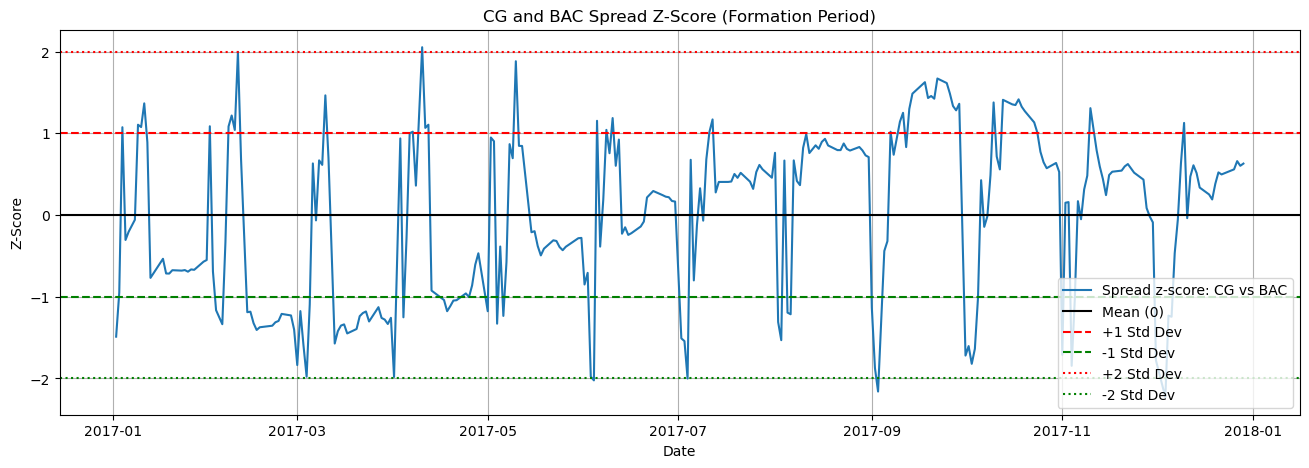

ADF p-value for spread (CG, BAC): 0.0000
Spread is stationary for CG and BAC.


In [ ]:
# In-sample test: analyze the spread behavior for each cointegrated pair
for i in range(len(cointegrated_pairs)):
    s1 = cointegrated_pairs.loc[i, 's1']
    s2 = cointegrated_pairs.loc[i, 's2']
    
    # Use formation period data
    y = log_prices_form[s1]
    x = log_prices_form[s2]

    # Regress y on x
    model = sm.OLS(y, sm.add_constant(x)).fit()
    hedge_ratio = model.params[1]
    
    # Create spread
    spread = y - hedge_ratio * x
    zscore = (spread - spread.mean()) / spread.std()

    # Plot spread and z-score
    plt.figure(figsize=(16, 5))
    line_z = plt.plot(zscore, label=f'Spread z-score: {s1} vs {s2}')
    line_0 = plt.axhline(0, color='black', label='Mean (0)')
    line_1 = plt.axhline(1, color='red', linestyle='--', label='+1 Std Dev')
    line_m1 = plt.axhline(-1, color='green', linestyle='--', label='-1 Std Dev')
    line_2 = plt.axhline(2, color='red', linestyle=':', label='+2 Std Dev')
    line_m2 = plt.axhline(-2, color='green', linestyle=':', label='-2 Std Dev')

    plt.title(f'{s1} and {s2} Spread Z-Score (Formation Period)')
    plt.xlabel("Date")
    plt.ylabel("Z-Score")
    plt.grid(True)
    plt.legend(loc='best')
    plt.show()

    # Conduct ADF test on spread again
    adf_test = adfuller(spread)
    print(f"ADF p-value for spread ({s1}, {s2}): {adf_test[1]:.4f}")

    if adf_test[1] < 0.05:
        # Incorporate 
        print(f"Spread is stationary for {s1} and {s2}.")
    else:
        # Remove from cointegrated pairs
        cointegrated_pairs = cointegrated_pairs.drop(i)
        print(f"Spread is not stationary for {s1} and {s2}. \nWe kick this pair out.")

## Out of Sample

In [ ]:
def buy_and_hold_portfolio(s1, s2, returns_trade):
    """
    Builds a buy-and-hold portfolio for s1 and s2 with 50/50 allocation.
    """
    # Equal weights
    weights = 0.5

    # Portfolio returns
    bnh_returns = weights * returns_trade[s1] + weights * returns_trade[s2]
    cumret_bnh = (bnh_returns + 1).cumprod()

    return bnh_returns, cumret_bnh

def calculate_metrics(cumret_series):
    rets = cumret_series.pct_change().dropna()
    total_return = cumret_series[-1] / cumret_series[0] - 1
    apr = (1 + total_return) ** (252 / len(rets)) - 1
    sharpe = np.sqrt(252) * np.nanmean(rets) / np.nanstd(rets)
    return total_return, apr, sharpe

def calculate_metrics_add(ret):
    '''
    Calculate additional performance metrics from daily returns.
    '''
    best_day = np.max(ret)
    worst_day = np.min(ret)
    pct_days_up = len(ret[ret > 0]) / len(ret)
    pct_days_down = len(ret[ret < 0]) / len(ret)
    avg_daily_gain = np.mean(ret[ret > 0]) if len(ret[ret > 0]) > 0 else 0
    sd_pos_ret = np.std(ret[ret > 0]) if len(ret[ret > 0]) > 0 else 0
    avg_daily_loss = np.mean(ret[ret < 0]) if len(ret[ret < 0]) > 0 else 0
    sd_neg_ret = np.std(ret[ret < 0]) if len(ret[ret < 0]) > 0 else 0

    return {
        'Best day': best_day,
        'Worst day': worst_day,
        '% days up': pct_days_up,
        '% days down': pct_days_down,
        'Avg gain': avg_daily_gain,
        'Std gain': sd_pos_ret,
        'Avg loss': avg_daily_loss,
        'Std loss': sd_neg_ret
    }

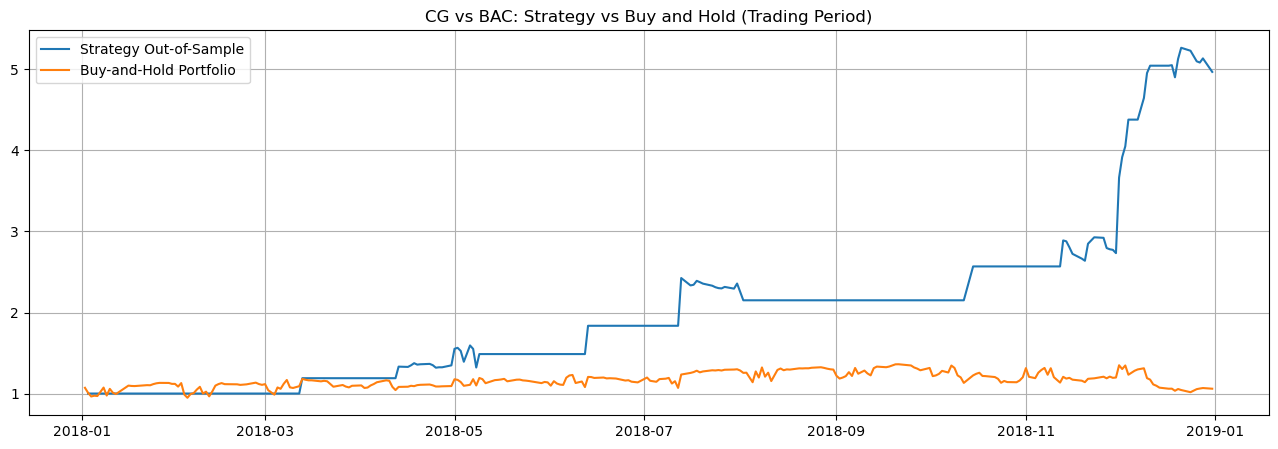

In [14]:
# Create a dictionary to store the results
metrics_dict = {}

for i in range(len(cointegrated_pairs)):
    s1 = cointegrated_pairs.loc[i, 's1']
    s2 = cointegrated_pairs.loc[i, 's2']
    pair_label = f"{s1}-{s2}"

    # Regression on formation data
    y_train = log_prices_form[s1]
    x_train = log_prices_form[s2]
    model = sm.OLS(y_train, sm.add_constant(x_train)).fit()
    hedge_ratio = model.params[1]

    # Spread and z-score in trading period
    spread_trade = log_prices_trade[s1] - hedge_ratio * log_prices_trade[s2]
    spread_mean = spread_trade.mean()
    spread_std = spread_trade.std()
    zscore_trade = (spread_trade - spread_mean) / spread_std

    # Trading signals
    entry_signal = np.where(zscore_trade > 2, -1, np.where(zscore_trade < -2, 1, 0))
    exit_signal = np.where(abs(zscore_trade) < 0.5, 0, np.nan)

    # Build positions
    positions = pd.Series(index=zscore_trade.index, dtype=float)
    current_pos = 0
    for j, z in enumerate(zscore_trade):
        if entry_signal[j] != 0:
            current_pos = entry_signal[j]
        elif not np.isnan(exit_signal[j]):
            current_pos = 0
        positions.iloc[j] = current_pos

    # Strategy returns
    pair_returns = returns_trade[s1] - hedge_ratio * returns_trade[s2]
    strategy_returns = positions.shift() * pair_returns
    cumulative_returns = (strategy_returns + 1).cumprod()

    # Buy-and-hold returns
    bnh_returns, cumret_bnh = buy_and_hold_portfolio(s1, s2, returns_trade)

    # === Calculate metrics ===
    # Strategy
    strat_metrics = calculate_metrics_add(strategy_returns.dropna())
    strat_total, strat_apr, strat_sharpe = calculate_metrics(cumulative_returns.dropna())
    strat_metrics.update({
        "Total Return": strat_total,
        "APR": strat_apr,
        "Sharpe": strat_sharpe
    })
    metrics_dict[f'{pair_label} Algorithm'] = strat_metrics

    # Buy & Hold
    bnh_metrics = calculate_metrics_add(bnh_returns.dropna())
    bnh_total, bnh_apr, bnh_sharpe = calculate_metrics(cumret_bnh.dropna())
    bnh_metrics.update({
        "Total Return": bnh_total,
        "APR": bnh_apr,
        "Sharpe": bnh_sharpe
    })
    metrics_dict[f'{pair_label} Buy and Hold'] = bnh_metrics

    # Individual Stock: s1
    s1_ret = returns_trade[s1].dropna()
    s1_cumret = (s1_ret + 1).cumprod()
    s1_metrics = calculate_metrics_add(s1_ret)
    s1_total, s1_apr, s1_sharpe = calculate_metrics(s1_cumret.dropna())
    s1_metrics.update({
        "Total Return": s1_total,
        "APR": s1_apr,
        "Sharpe": s1_sharpe
    })
    metrics_dict[f'{s1} Indiv Stock'] = s1_metrics

    # Individual Stock: s2
    s2_ret = returns_trade[s2].dropna()
    s2_cumret = (s2_ret + 1).cumprod()
    s2_metrics = calculate_metrics_add(s2_ret)
    s2_total, s2_apr, s2_sharpe = calculate_metrics(s2_cumret.dropna())
    s2_metrics.update({
        "Total Return": s2_total,
        "APR": s2_apr,
        "Sharpe": s2_sharpe
    })
    metrics_dict[f'{s2} Indiv Stock'] = s2_metrics

    # === Plot ===
    plt.figure(figsize=(16, 5))
    plt.plot(cumulative_returns, label='Strategy Out-of-Sample')
    plt.plot(cumret_bnh, label='Buy-and-Hold Portfolio')
    plt.title(f'{s1} vs {s2}: Strategy vs Buy and Hold (Trading Period)')
    plt.legend()
    plt.grid(True)
    plt.show()

In [ ]:
# Convert to dataframe and transpose
metrics_df = pd.DataFrame(metrics_dict).round(6)

# Display the result
display(metrics_df)

,CG-BAC Algorithm,CG-BAC Buy and Hold,CG Indiv Stock,BAC Indiv Stock
Best day,0.340937,0.154224,0.316095,0.211482
Worst day,-0.148274,-0.125758,-0.187951,-0.171537
% days up,0.120000,0.496377,0.467391,0.496377
% days down,0.123636,0.503623,0.514493,0.467391
Avg gain,0.078787,0.029336,0.055192,0.024374
Std gain,0.089815,0.032592,0.065015,0.040407
Avg loss,-0.022612,-0.026845,-0.046890,-0.025002
Std loss,0.028215,0.026897,0.049326,0.036402
Total Return,3.969840,-0.010534,-0.355815,-0.160769
APR,3.369499,-0.009657,-0.331680,-0.148376
